In [1]:
import pyrite
from scipy.optimize import differential_evolution, minimize
from tqdm.notebook import tqdm, trange
import numpy as np
import pandas as pd

Dihedral angles: 6


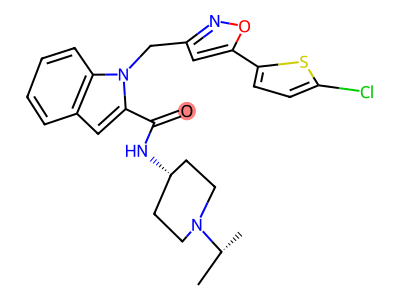

In [2]:
#load data
ligand = pyrite.Mol.from_sdf('examples/input_files/factor_x_ligand.sdf')

print('Dihedral angles:', len(ligand.dihedral_angles))
ligand.set_draw_options({'highlight': 'center'})
ligand.svg

In [3]:
receptor = pyrite.Mol.from_pdb('examples/input_files/factor_x.pdb')
receptor.viewer

HTML(value='<iframe srcdoc="&lt;div id=&quot;3dmolviewer_1784748236539691&quot;  style=&quot;position: relativ…

In [4]:
ligand.viewer

HTML(value='<iframe srcdoc="&lt;div id=&quot;3dmolviewer_17847482365867798&quot;  style=&quot;position: relati…

In [5]:
binding_site = pyrite.bounds.RectangularBounds.autobox(ligand, padding=1.0)
grid_size = 1 #(0,1)
pocket = pyrite.bounds.Pocket.from_mol(receptor, grid_size=1.4, neighbors=26, gt_distance_to_outside=10, solvent_accessible=False).intersect(binding_site,padding=1.0)
# print(pyrite.Viewer(receptor).view.show())
pyrite.Viewer(receptor, pocket).show()

HTML(value='<iframe srcdoc="&lt;div id=&quot;3dmolviewer_17847482388104901&quot;  style=&quot;position: relati…

In [6]:
init_vars = ligand.place_in(pocket, n_positions=4000, n_conformations=20)
viewer = pyrite.Viewer(receptor)
viewer.add_v(ligand, init_vars[:59], slider=False, options={'colorscheme': 'magentaCarbon'})

viewer.show()

/Users/martvanderlugt/Dev/Pyrite/pyrite/bounds.py:309: RuntimeWarning: divide by zero encountered in matmul
  return np.matmul(np.array(v), self._rotation_matrix) + self._at
/Users/martvanderlugt/Dev/Pyrite/pyrite/bounds.py:309: RuntimeWarning: overflow encountered in matmul
  return np.matmul(np.array(v), self._rotation_matrix) + self._at
/Users/martvanderlugt/Dev/Pyrite/pyrite/bounds.py:309: RuntimeWarning: invalid value encountered in matmul
  return np.matmul(np.array(v), self._rotation_matrix) + self._at
[21:23:58] Molecule does not have explicit Hs. Consider calling AddHs()


HTML(value='<iframe srcdoc="&lt;div id=&quot;3dmolviewer_1784748239032814&quot;  style=&quot;position: relativ…

In [7]:
#First scoring fucntion based on the pocket
overlap_scoring = pyrite.scoring.DistanceToPocket(ligand, pocket) + 0.1 * pyrite.scoring.InternalEnergy(ligand)


[21:23:59] Molecule does not have explicit Hs. Consider calling AddHs()


In [8]:
#Filter out the poses and get top 100
k = 100

energies = np.zeros(len(init_vars))

for i, var in tqdm(enumerate(init_vars), total=len(init_vars)):
    energies[i] = overlap_scoring.step(var, ligand)

sorted_indices = np.argsort(energies)
filtered_vars = init_vars[sorted_indices[:k]]

  0%|          | 0/4000 [00:00<?, ?it/s]

In [9]:
#Searching
searching_func = "pocket overlap"
if searching_func == "Vina":
    scoring = (-0.035579 * pyrite.Gaussian(ligand, receptor, offset=0.0, width=0.5, k=400)
                + -0.005156 * pyrite.scoring.Gaussian(ligand, receptor, offset=3.0, width=2.0, k=400)
                + 0.840245 * pyrite.scoring.Repulsion(ligand, receptor, offset=0.0, k=400)
                + -0.035069 * pyrite.scoring.Hydrophobic(ligand, receptor, good=0.5, bad=1.5, k=400)
                + -0.587439 * pyrite.scoring.NonDirHBond(ligand, receptor, good=-0.7, bad=0.0, k=400)
                + 1e-2 * pyrite.scoring.InternalEnergy(ligand)) / (1 + ((0.1 * (1.923 + 1)) * (NumTors(ligand))) / 5)
elif searching_func == "PLP":
    scoring = pyrite.scoring.PlantsPLP(ligand, receptor) + 1e-2 * pyrite.scoring.DistanceToPcket.InternalEnergy(ligand)
else: # use pocket overlap
    scoring = overlap_scoring

print(scoring.get_score())

10.257878680558314


In [10]:
n_poses = 4 # @param {"type":"slider","min":1,"max":20,"step":1}

results = []

crowding = pyrite.scoring.Crowding(ligand, offset=4)
func = scoring + 1e1 * crowding

for i in trange(n_poses):
    init_vars_idx = np.random.choice(len(filtered_vars), size=20, replace=True)
    init_vars_run = filtered_vars[init_vars_idx]


    res = differential_evolution(func.step, pocket.get_bounds(ligand), args={ligand}, rng=42, init=init_vars_run, strategy='best1bin', maxiter=1000, polish=False)
    results.append(res)

    crowding.register_pose(res.x)


  0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
rmsd = pyrite.scoring.RMSD(ligand)

rmsds = [rmsd.step(res.x, ligand) for res in results]
score = [scoring.step(res.x, ligand) for res in results]

df = pd.DataFrame(
    {'fun': [res.population_energies[0] for res in results], 'score': score, 'RMSD': rmsds,
     'v': [res.x for res in results]})
df.sort_values('score', inplace=True)
df.reset_index(inplace=True, drop=True)
pyrite.Viewer(receptor, options={'stickresidues': ['HEM']}).add_v(ligand, df['v'].values, slider=True,
                                                           options={'colorscheme': 'magentaCarbon'}).show()
print(df[['score', 'RMSD']])

      score      RMSD
0  6.797260  8.594485
1  7.062149  4.362724
2  7.511054  6.779470
3  7.976167  8.373172


In [12]:
refining_func = "PLP"
if refining_func == "Vina":
    scoring = (-0.035579 *  pyrite.scoring.Gaussian(ligand, receptor, offset=0.0, width=0.5, k=400)
                + -0.005156 *  pyrite.scoring.Gaussian(ligand, receptor, offset=3.0, width=2.0, k=400)
                + 0.840245 *  pyrite.scoring.Repulsion(ligand, receptor, offset=0.0, k=400)
                + -0.035069 *  pyrite.scoring.Hydrophobic(ligand, receptor, good=0.5, bad=1.5, k=400)
                + -0.587439 *  pyrite.scoring.NonDirHBond(ligand, receptor, good=-0.7, bad=0.0, k=400)
                + 1e-2 *  pyrite.scoring.InternalEnergy(ligand)) / (1 + ((0.1 * (1.923 + 1)) * (NumTors(ligand))) / 5)
else:
    scoring =  pyrite.scoring.PlantsPLP(ligand, receptor) + 1e-2 *  pyrite.scoring.InternalEnergy(ligand)

print(scoring.get_score())

-93.97154317013758


[21:24:01] Molecule does not have explicit Hs. Consider calling AddHs()


In [13]:
refine_results = []

for i, v in tqdm(enumerate(df['v'].values), total=len(df)):
    r = minimize(scoring.step, v, args=(ligand,), method='L-BFGS-B', options={'eps': 1e-2}, tol=1e-4)
    refine_results.append(r)

  0%|          | 0/4 [00:00<?, ?it/s]

In [14]:
rmsds = [rmsd.step(res.x, ligand) for res in refine_results]

df = pd.DataFrame({'score': [res.fun for res in refine_results], 'RMSD': rmsds, 'v': [res.x for res in refine_results]})
df.sort_values('score', inplace=True)
pyrite.Viewer(receptor, ligand, options={'stickresidues': ['HEM']}).add_v(ligand, [res.x for res in refine_results], slider=True,
                               options={'colorscheme': 'magentaCarbon'}).show()
df[['score', 'RMSD']]

,score,RMSD
1,-53.168375,4.181429
0,-35.469146,9.093512
3,-34.765303,8.119656
2,-25.770045,6.801227


In [15]:
df

,score,RMSD,v
1,-53.168375,4.181429,"[2.059517659934229, -0.03289729065726225, -2.3..."
0,-35.469146,9.093512,"[-1.7698960059673974, 1.301833014000327, -4.15..."
3,-34.765303,8.119656,"[-1.668734552809417, 0.9648035685186673, 2.510..."
2,-25.770045,6.801227,"[1.6059078515560972, 1.2986551406504343, -3.60..."


In [16]:
view = pyrite.Viewer(receptor)
view.add_v(ligand, df['v']).show()
